In [10]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from itertools import combinations

# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración
# -----------------------------------------------------------------------
# para poder visualizar todas las columnas de los DataFrames
pd.set_option('display.max_columns', None) 

In [11]:
# Read the CSV file
df = pd.read_csv('SPF_INEE_clean.csv')
df.head(2)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance_Levels
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67,2
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [13]:
numericas = df.select_dtypes(include=np.number)
numericas_comb = list(combinations(numericas, 2))
numericas_comb

[('Hours_Studied', 'Attendance'),
 ('Hours_Studied', 'Sleep_Hours'),
 ('Hours_Studied', 'Previous_Scores'),
 ('Hours_Studied', 'Tutoring_Sessions'),
 ('Hours_Studied', 'Physical_Activity'),
 ('Hours_Studied', 'Exam_Score'),
 ('Hours_Studied', 'Performance_Levels'),
 ('Attendance', 'Sleep_Hours'),
 ('Attendance', 'Previous_Scores'),
 ('Attendance', 'Tutoring_Sessions'),
 ('Attendance', 'Physical_Activity'),
 ('Attendance', 'Exam_Score'),
 ('Attendance', 'Performance_Levels'),
 ('Sleep_Hours', 'Previous_Scores'),
 ('Sleep_Hours', 'Tutoring_Sessions'),
 ('Sleep_Hours', 'Physical_Activity'),
 ('Sleep_Hours', 'Exam_Score'),
 ('Sleep_Hours', 'Performance_Levels'),
 ('Previous_Scores', 'Tutoring_Sessions'),
 ('Previous_Scores', 'Physical_Activity'),
 ('Previous_Scores', 'Exam_Score'),
 ('Previous_Scores', 'Performance_Levels'),
 ('Tutoring_Sessions', 'Physical_Activity'),
 ('Tutoring_Sessions', 'Exam_Score'),
 ('Tutoring_Sessions', 'Performance_Levels'),
 ('Physical_Activity', 'Exam_Score'),


In [14]:
matrix = numericas.corr()
matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Performance_Levels
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455,0.372403
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072,0.473231
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022,-0.020172
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079,0.141386
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525,0.138891
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824,0.033386
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000,0.827459
Performance_Levels,0.372403,0.473231,-0.020172,0.141386,0.138891,0.033386,0.827459,1.000000


In [15]:
mascara = np.triu(np.ones_like(matrix, dtype=bool))

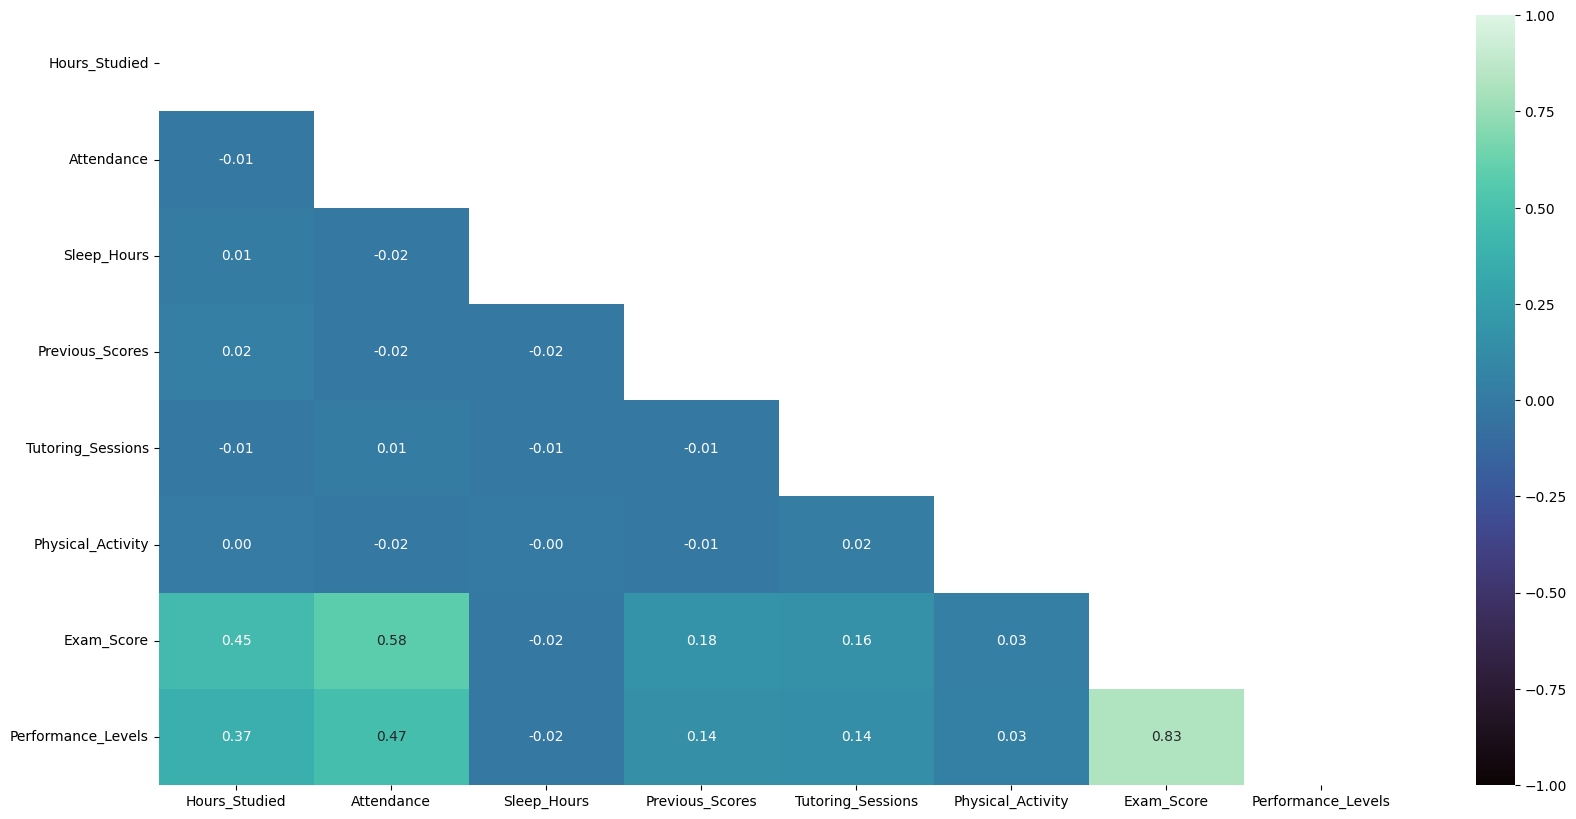

In [16]:
plt.figure(figsize=(20,10))
sns.heatmap(matrix, 
            annot=True, 
            fmt='.2f', 
            cmap= 'mako', 
            vmin=-1, vmax='1', 
            mask = mascara);